# CS 5864 Homework 4, Part 2: Diffusion

Follow the lead / steps from the [UC Berkeley assignment](https://cal-cs180.github.io/fa24/hw/proj5/partb.html) for this to the extent they don't conflict with the instructions on Canvas.

## Setup your environment

In [24]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch # added
from torch import optim # added
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import os 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


## Visualization helper function

In [25]:
def visualize_images_with_titles(images: torch.Tensor, column_names: list[str]):
    """
    Visualize images as a grid and title the columns with the provided names.

    Args:
        images: (N, C, H, W) tensor of images, where N is (number of rows * number of columns)
        column_names: List of column names for the titles.

    Example usage:
    visualize_images_with_titles(torch.randn(16, 1, 32, 32), ['1', '2', '3', '4'])
    """
    num_images, num_columns = images.shape[0], len(column_names)
    assert num_images % num_columns == 0, 'Number of images must be a multiple of the number of columns.'

    num_rows = num_images // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 1, num_rows * 1))

    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if i < num_columns:
            ax.set_title(column_names[i % num_columns])

    plt.tight_layout()
    plt.show()


# Part 1: Training a Single-step Denoising UNet

## Implementing Simple and Composed Ops

In [26]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.Conv = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1),
                                  nn.BatchNorm2d(out_channels),
                                  nn.GELU())


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.Conv(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.Conv = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 2, 1),
                                nn.BatchNorm2d(out_channels),
                                nn.GELU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.Conv(x)

class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.Conv = nn.Sequential(nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
                                nn.BatchNorm2d(out_channels),
                                nn.GELU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.Conv(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.Sequential(nn.AvgPool2d(7),
                                  nn.GELU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.pool(x)


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.Conv = nn.Sequential(nn.ConvTranspose2d(in_channels, in_channels, 7, 7, 0),
                        nn.BatchNorm2d(in_channels),
                        nn.GELU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.Conv(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.conv_block = nn.Sequential(Conv(in_channels, out_channels),
                                        Conv(out_channels, out_channels))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(x)



class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv_block = nn.Sequential(DownConv(in_channels, out_channels),
                                        ConvBlock(out_channels, out_channels))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv_block = nn.Sequential(UpConv(in_channels, out_channels),
                                        ConvBlock(out_channels, out_channels))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(x)

## Implementing Unconditional UNet

In [27]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
        out_channels: int
    ):
        super().__init__()

        
        self.x1 = ConvBlock(in_channels, num_hiddens)
        self.x2 = DownBlock(num_hiddens, num_hiddens)
        self.x3 = DownBlock(num_hiddens, num_hiddens*2)
        self.x4 = Flatten()
        self.x5 = Unflatten(num_hiddens*2)

        self.x6 = UpBlock(num_hiddens*4, num_hiddens)
        self.x7 = UpBlock(num_hiddens*2, num_hiddens)
        self.x8 = ConvBlock(num_hiddens*2, num_hiddens)
        self.x9 = nn.Conv2d(num_hiddens, out_channels, 3, 1, 1)



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.x1(x)
        x2 = self.x2(x1)
        x3 = self.x3(x2)
        x4 = self.x4(x3)
        x5 = self.x5(x4)

        #differential padding for the unflattening section...
        diff_h = x3.shape[-2] - x5.shape[-2]
        diff_w = x3.shape[-1] - x5.shape[-1]
        x5 = torch.nn.functional.pad(x5, (diff_w//2, diff_w - diff_w//2, 
                                           diff_h//2, diff_h - diff_h//2))
        x6 = torch.concatenate([x3, x5], dim = 1)
        x7 = torch.concatenate([x2, self.x6(x6)], dim = 1)
        x8 = torch.concatenate([x1, self.x7(x7)], dim = 1)
        x9 = self.x8(x8)
        xf = self.x9(x9)

        return xf

## Visualizing the noising process

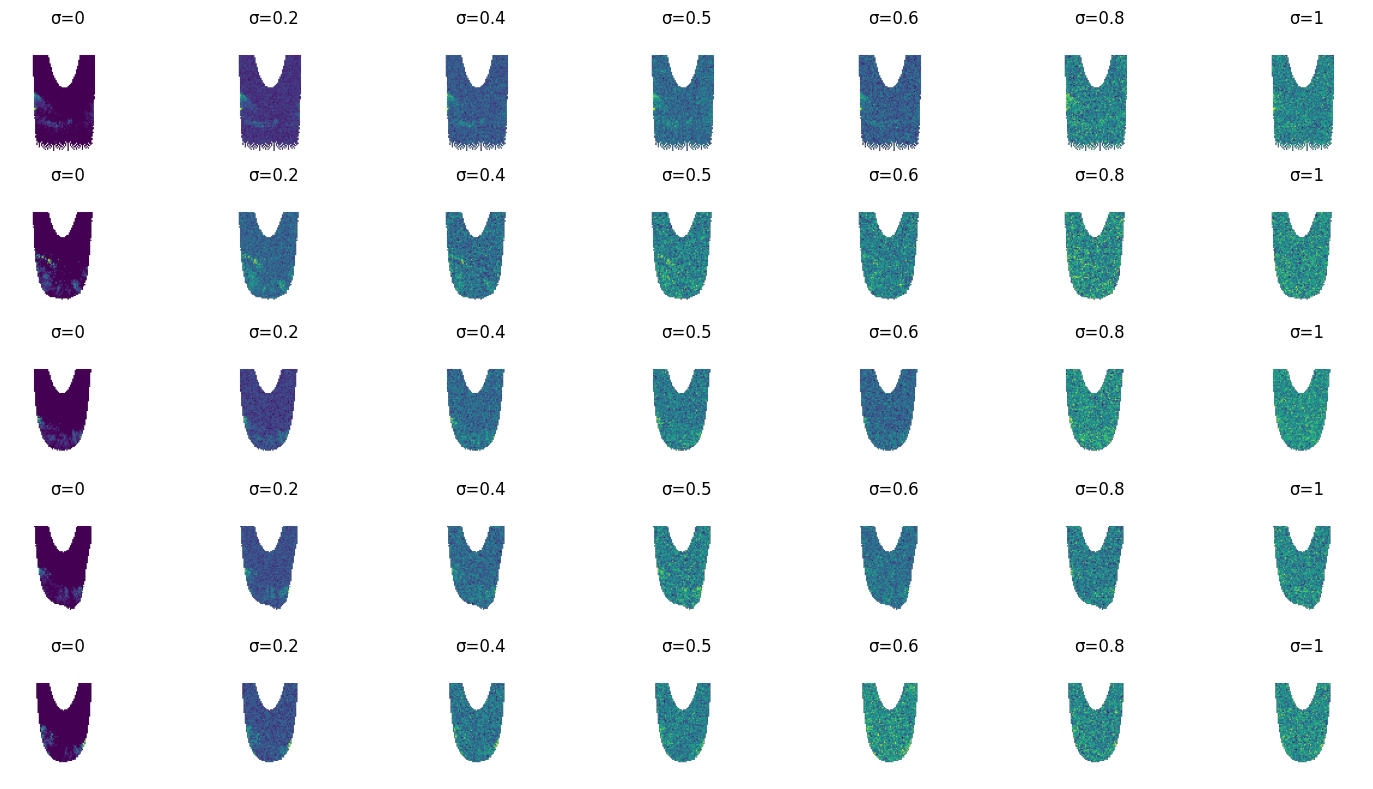

In [28]:
import numpy as np
import utils
from torch.utils.data import Subset, random_split

fp_pd = r'E:\ml_aurora' #parent directory
dataset = utils.GUVI_dataset(
    input_dir=os.path.join(fp_pd, 'guvi_paired_data', 'inputs'),
    image_dir=os.path.join(fp_pd, 'guvi_paired_data', 'images'))
subset_indices = list(range(128*50)) 
dataset = Subset(dataset, subset_indices)


sigma = [0, .2, .4, .5, .6, .8, 1]

plt.figure(figsize=(15, 8))
num_rows = 5
num_cols = len(sigma)

for i in range(num_rows):               
    image = dataset[i]['image']

    for j, s in enumerate(sigma):      
        idx = i * num_cols + j + 1       
        gaussian = np.random.normal(0, s, (image.shape[0],image.shape[1]))#scale

        plt.subplot(num_rows, num_cols, idx)
        plt.imshow(image+gaussian)
        plt.title(f"σ={s}")
        plt.axis('off')

plt.tight_layout()
plt.show()


## Training a Single-Step Unconditional UNet

- Plot the loss curve
- Sample results on the test set

Train Loss: 0.0502: 100%|██████████| 280/280 [03:23<00:00,  1.38it/s]


Avg epoch loss:  0.15


Train Loss: 0.0701: 100%|██████████| 280/280 [01:48<00:00,  2.58it/s]


Avg epoch loss:  0.08


Train Loss: 0.1432: 100%|██████████| 280/280 [01:48<00:00,  2.59it/s]


Avg epoch loss:  0.07


Train Loss: 0.0296: 100%|██████████| 280/280 [01:48<00:00,  2.59it/s]


Avg epoch loss:  0.06


Train Loss: 0.0363: 100%|██████████| 280/280 [01:47<00:00,  2.61it/s]

Avg epoch loss:  0.05


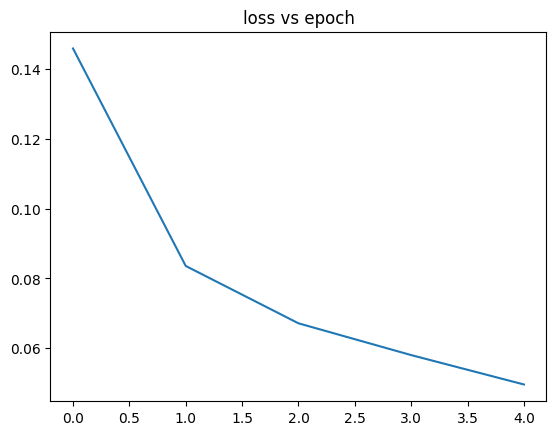

In [29]:
from tqdm import tqdm
import torchvision.transforms as transforms
device = 'cuda'

fp_pd = r'E:\ml_aurora' #parent directory
trans = transforms.RandomErasing(value = -10)
dataset = utils.GUVI_dataset(input_dir=os.path.join(fp_pd, 'guvi_paired_data', 'inputs'),
                              image_dir=os.path.join(fp_pd, 'guvi_paired_data', 'images'),
                                transforms = None)
subset_indices = torch.randperm(len(dataset))[:128*100]
dataset = Subset(dataset, subset_indices)
train_size = int(.70 * len(dataset))
val_size = len(dataset) - train_size


train_set, val_set = random_split(dataset, [train_size, val_size])
train_dataloader = DataLoader(train_set,
                            batch_size=32,
                            shuffle=True,
                        )
val_dataloader = DataLoader(val_set, 
                            batch_size=32,
                            shuffle=True,
                        )

impute = -0.010262/ 0.037237

model = UnconditionalUNet(1, 128, 2).to(device)

criterion = nn.MSELoss()
solver = optim.Adam(model.parameters(), lr = 1e-4)
all_loss = []
for epoch in range(5):
    loop = tqdm(train_dataloader)
    loss_list = []
    for batch in loop:
        
        hemisphere = batch['hemisphere']
        mask = batch['og_nan_mask'].unsqueeze(1)
        batch = batch['image'].type(torch.float32).unsqueeze(1)
        batch[torch.isnan(batch)] = impute
        
        #add noise
        noise = torch.normal(mean=0, std=0.5, size=batch.shape)
        input = (batch + noise)

        #predictions
        preds = model(input.to(device))
        preds = preds[torch.arange(preds.shape[0]), hemisphere].unsqueeze(1)


        loss = criterion(preds[~mask], batch[~mask].to(device))
        solver.zero_grad()  
        loss.backward()
        solver.step()

        loop.set_description(f"Train Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
    print('Avg epoch loss: ', round(np.mean(np.array(loss_list)),2))
    all_loss.append(np.mean(np.array(loss_list)))
plt.figure()
plt.title('loss vs epoch')
plt.plot(all_loss)
plt.show()

## Out-of-Distribution Testing

In [30]:
device = 'cuda'

with torch.no_grad():
    loss_list = []
    loop = tqdm(val_dataloader)
    for batch in loop:
        
        hemisphere = batch['hemisphere']
        mask = batch['og_nan_mask'].unsqueeze(1)
        batch = batch['image'].type(torch.float32).unsqueeze(1)
        batch[torch.isnan(batch)] = impute
        #add noise
        noise = torch.normal(mean=0, std=0.5, size=batch.shape)
        input = batch + noise

        #predictions
        preds = model(input.to(device))
        preds = preds[torch.arange(preds.shape[0]), hemisphere].unsqueeze(1)

        
        loss = criterion(preds[~mask], batch[~mask].to(device))

        loop.set_description(f"Train Loss: {loss.item():.4f}")
        loss_list.append(loss.item())


print('Avg loss out of distribution: ', round(np.mean(np.array(loss_list)),2))

Train Loss: 0.0343: 100%|██████████| 120/120 [01:08<00:00,  1.76it/s]

Avg loss out of distribution:  0.04


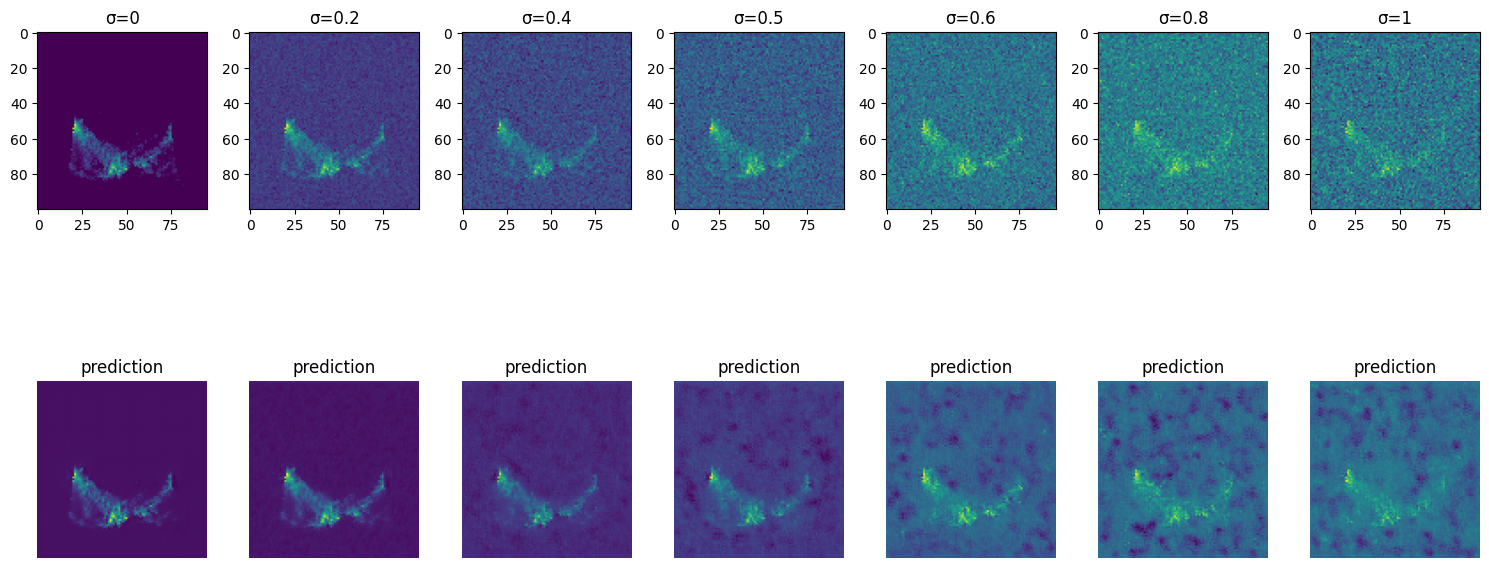

In [31]:
sigma = [0, .2, .4, .5, .6, .8, 1]

img = batch[0].type(torch.float32).unsqueeze(1)
img[torch.isnan(img)] = impute
plt.figure(figsize=(15, 8))
num_cols = len(sigma)

for j, s in enumerate(sigma):      

    noise = torch.normal(mean=0, std=s, size=img.shape)
    input = img + noise
    
    with torch.no_grad():
        preds = model(input.to(device))
    
    plt.subplot(2, num_cols, j+1)
    plt.title(f"σ={s}")

    plt.imshow(input[0][0])

    plt.subplot(2, num_cols, j+num_cols+1)
    plt.imshow(preds.cpu()[0,0])
    plt.title('prediction')
    plt.axis('off')

plt.tight_layout()
plt.show()


# Part 2: Training a Diffusion Model

## Implementing a Time-conditioned UNet

In [46]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.model = nn.Sequential(
                                    nn.Linear(in_channels, out_channels),
                                    nn.GELU(),
                                    nn.Linear(out_channels, out_channels)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        num_classes: int,
        num_hiddens: int

    ):
        super().__init__()

        self.num_hiddens = num_hiddens

        self.x1 = ConvBlock(in_channels, num_hiddens)
        self.x2 = DownBlock(num_hiddens, num_hiddens)
        self.x3 = DownBlock(num_hiddens, num_hiddens*2)
        self.x4 = Flatten()
        self.x5 = Unflatten(num_hiddens*2)

        self.x6 = UpBlock(num_hiddens*4, num_hiddens)
        self.x7 = UpBlock(num_hiddens*2, num_hiddens)
        self.x8 = ConvBlock(num_hiddens*2, num_hiddens)
        self.x9 = nn.Conv2d(num_hiddens, out_channels, 3, 1, 1)

        self.fc1 = FCBlock(1, self.num_hiddens*2)
        self.fc2 = FCBlock(1, self.num_hiddens)

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """


        x1 = self.x1(x)
        x2 = self.x2(x1)
        x3 = self.x3(x2)
        x4 = self.x4(x3)
        x5 = self.x5(x4)

        #differential padding for the unflattening section...
        diff_h = x3.shape[-2] - x5.shape[-2]
        diff_w = x3.shape[-1] - x5.shape[-1]
        x5 = torch.nn.functional.pad(x5, (diff_w//2, diff_w - diff_w//2, 
                                           diff_h//2, diff_h - diff_h//2))

        #these may need to be normalized, move to self
        t1 = self.fc1(t)[:,:,None,None]
        t2 = self.fc2(t)[:,:,None,None]


        x6 = torch.concatenate([x3, x5 + t1], dim = 1) 

        x7 = torch.concatenate([x2, self.x6(x6) + t2], dim = 1) 
        x8 = torch.concatenate([x1, self.x7(x7)], dim = 1)
        x9 = self.x8(x8)
        xf = self.x9(x9)

        return xf

## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [47]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """

    ddpm ={
        'betas': np.linspace(beta1, beta2, num = num_ts), #might need to be -1
        'alphas': 1 - np.linspace(beta1, beta2, num = num_ts) ,
        'alpha_bars': np.cumprod(1 - np.linspace(beta1, beta2, num = num_ts))
    }
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    return ddpm

In [78]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
        device = 'cuda'
    ):
        super().__init__()
        self.unet = unet.to(device)
        self.num_ts = num_ts
        self.p_uncond = p_uncond

        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """



        self.unet.train()

        t = torch.randint(0, self.num_ts, (x.shape[0],))
        eps = torch.randn_like(x)
        alpha_bar_t = torch.Tensor(self.ddpm_schedule["alpha_bars"][t]).view(-1, 1, 1, 1).to('cuda')

        
        xt = torch.sqrt(alpha_bar_t) * x.to('cuda') + torch.sqrt(1 - alpha_bar_t) * eps.to('cuda').to('cuda')
        t = t.type(torch.float).view(-1, 1).to('cuda')/self.num_ts


        output = self.unet(xt,t)
        eps = eps.to('cuda')

        return eps, output
        




    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        self.unet.eval()

        H, W = img_wh
        C = 1 

        alpha = torch.Tensor(self.ddpm_schedule['alphas']).to(device)          
        alpha_bar = torch.Tensor(self.ddpm_schedule['alpha_bars']).to(device) 
        beta  = torch.Tensor(self.ddpm_schedule['betas']).to(device)       

        all_imgs = []
        for i in range(25):     
            x_t = torch.randn(H, W, device=device)
            xtl = []
            for t in reversed(range(self.num_ts)):
                tt = torch.Tensor([t]).type(torch.float).view(-1, 1).to('cuda')/self.num_ts
                x_t = x_t.squeeze()
                print(tt.shape)
                print(x_t.shape)
                eps = self.unet(x_t[None,:,:], tt)

                x_p0 = (alpha_bar[t])**(-1/2) * (x_t - torch.sqrt(1 - alpha_bar[t]) * eps)

                coef1 = (torch.sqrt(alpha_bar[t-1]) * beta[t]) / (1 - alpha_bar[t])
                coef2 = (torch.sqrt(alpha[t]) * (1 - alpha_bar[t-1])) / (1 - alpha_bar[t])

                mean = coef1 * x_p0 + coef2 * x_t


                if t > 0:
                    x_t = mean + torch.sqrt(beta[t])* torch.randn_like(x_t)
                else:
                    x_t = mean

                xtl.append(x_t)
            all_imgs.append(xtl)
        return x_t, all_imgs



## Training the Time-conditioned UNet

- Plot the loss curve
- Sample results on the test set

In [79]:
from tqdm import tqdm
import numpy as np
from torch.utils.data import Subset

device = 'cuda'
dataset = utils.GUVI_dataset(input_dir=os.path.join(fp_pd, 'guvi_paired_data', 'inputs'),
                              image_dir=os.path.join(fp_pd, 'guvi_paired_data', 'images'),
                                transforms = None)
subset_indices = torch.randperm(len(dataset))[:128*1]
dataset = Subset(dataset, subset_indices)
train_size = int(.70 * len(dataset))
val_size = len(dataset) - train_size


train_set, val_set = random_split(dataset, [train_size, val_size])
train_dataloader = DataLoader(train_set,
                            batch_size=32,
                            shuffle=True,
                        )
val_dataloader = DataLoader(val_set, 
                            batch_size=32,
                            shuffle=True,
                        )

model = TimeConditionalUNet(in_channels = 1, out_channels = 2, num_classes = 1, num_hiddens = 64).to('cuda')
solver = optim.Adam(params= model.parameters(), lr = 1e-3)
num_ts = 300
ddpm_sched = ddpm_schedule(beta1= 1e-4, beta2= .02, num_ts = num_ts) 
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer = solver, gamma = .1**(1/20))

pipe = DDPM(unet = model)
diffusion_imgs = {}
all_loss = []
criterion = nn.MSELoss()

for epoch in range(20):
    loop = tqdm(train_dataloader)
    loss_list = []

    for batch in loop:
        
        hemisphere = batch['hemisphere']
        mask = batch['og_nan_mask'].unsqueeze(1)
        batch = batch['image'].type(torch.float32).unsqueeze(1)
        batch[torch.isnan(batch)] = impute
        
        #predictions
        eps, preds = pipe(batch)
        preds = preds[torch.arange(preds.shape[0]), hemisphere].unsqueeze(1)

        #loss
        loss = criterion(preds[~mask], batch[~mask].to(device))
        solver.zero_grad()  
        loss.backward()
        solver.step()

        loop.set_description(f"Train Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
        all_loss.append(loss.item())





    print(f'Epoch {epoch + 1} loss: ', round(np.mean(np.array(loss_list)),2))
    # all_loss.append(np.mean(np.array(loss_list)))
    scheduler.step()


    if (epoch == 5 - 1) | (epoch == 20 - 1):
        _, xt_list = pipe.sample(img_wh =(100,96))
        diffusion_imgs[f'{epoch + 1}'] = xt_list
    # ddpm_forward(model, ddpm_sched, batch, num_ts, eval = True)




Train Loss: 0.2594: 100%|██████████| 28/28 [00:10<00:00,  2.67it/s]


Epoch 1 loss:  0.45


Train Loss: 0.2775: 100%|██████████| 28/28 [00:04<00:00,  6.78it/s]


Epoch 2 loss:  0.33


Train Loss: 0.2144: 100%|██████████| 28/28 [00:04<00:00,  6.53it/s]


...

Train Loss: 0.1583: 100%|██████████| 28/28 [00:04<00:00,  6.55it/s]


Epoch 4 loss:  0.32


Train Loss: 0.1352: 100%|██████████| 28/28 [00:04<00:00,  6.56it/s]


Epoch 5 loss:  0.19
torch.Size([1, 1])
torch.Size([100, 96])


ValueError: expected 4D input (got 3D input)

In [80]:
if (epoch == 5 - 1) | (epoch == 20 - 1):
    _, xt_list = pipe.sample(img_wh =(100,96))
    diffusion_imgs[f'{epoch + 1}'] = xt_list

torch.Size([1, 1])
torch.Size([100, 96])


ValueError: expected 4D input (got 3D input)

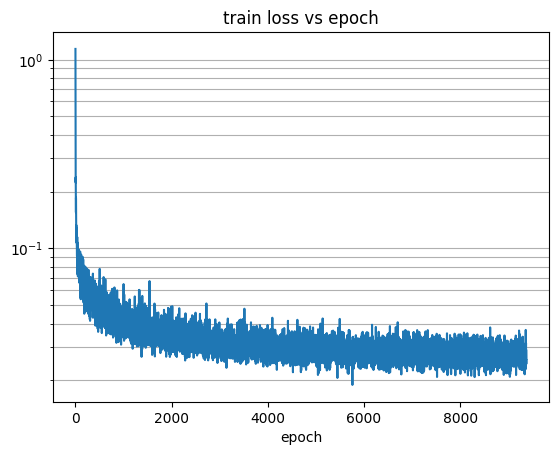

In [ ]:
plt.figure()
plt.plot(np.arange(len(all_loss)), all_loss)
plt.xlabel('epoch')
plt.title('train loss vs epoch')
plt.yscale('log')

# ✓ horizontal gridlines at every y tick
plt.grid(which='both', axis='y')

plt.show()


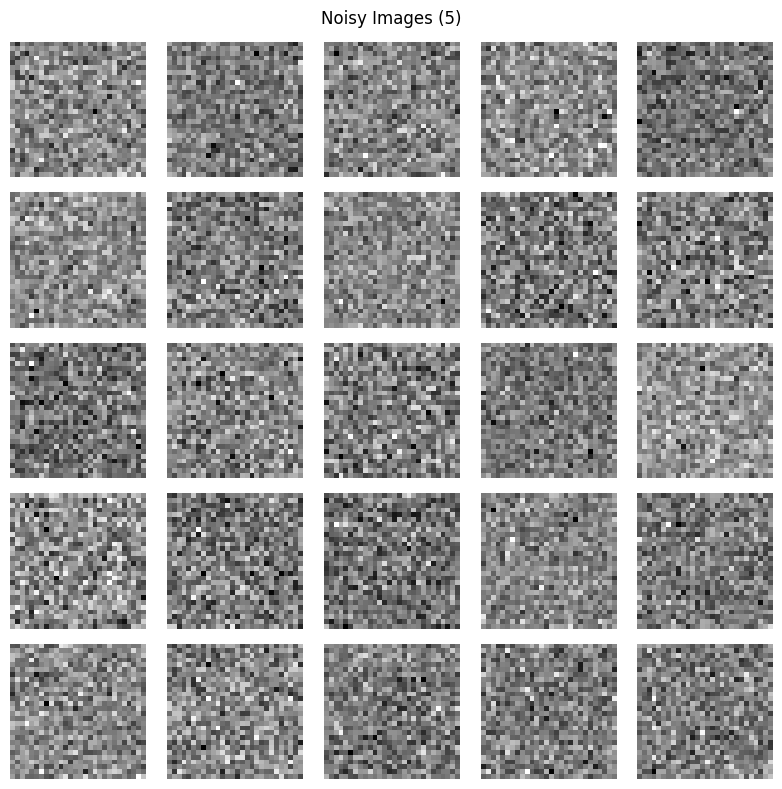

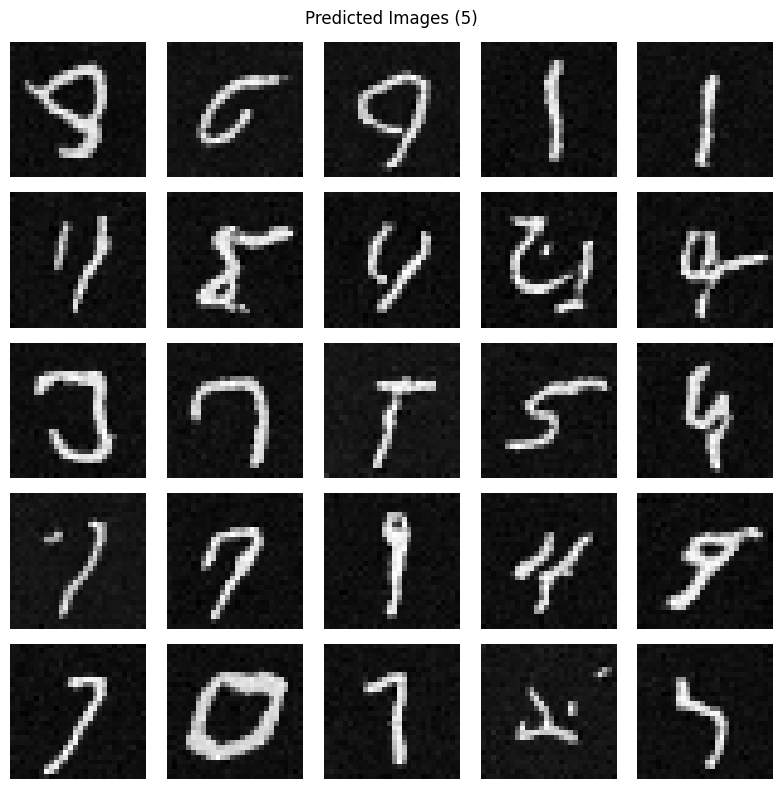

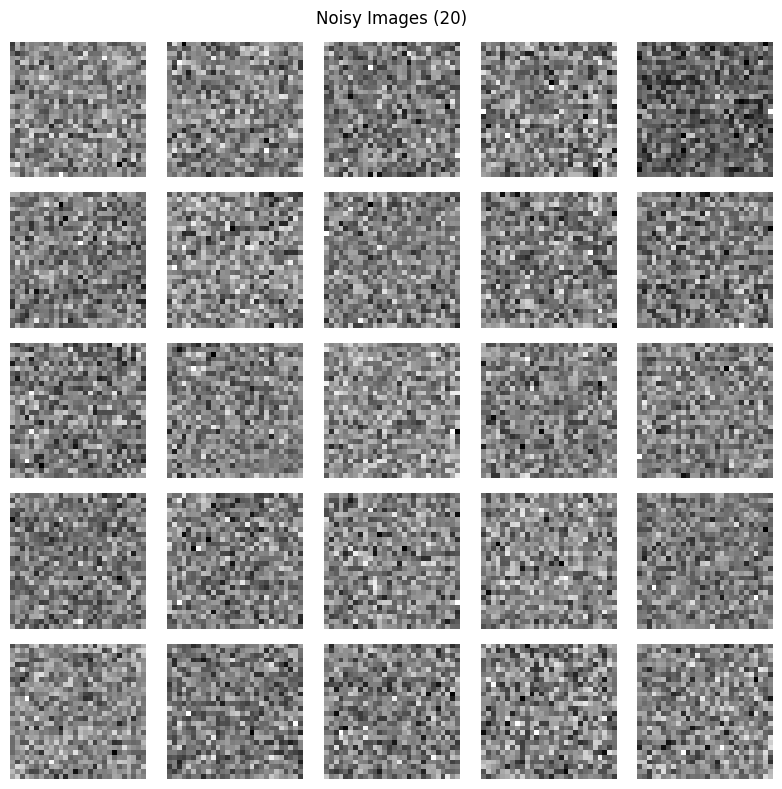

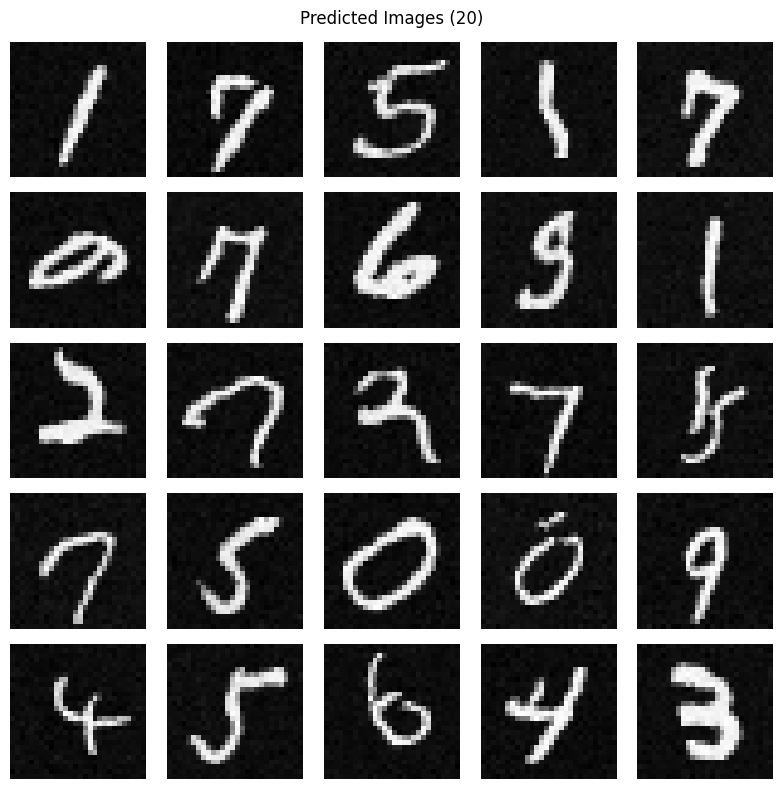

In [ ]:

import matplotlib.pyplot as plt

# assuming: diffusion_imgs[key] is a list of lists or tensors:
#   predictions[i][0] = noisy image
#   predictions[i][-1] = predicted image

for key in diffusion_imgs.keys():

    predictions = diffusion_imgs[key]   # list of 25 predictions

    # --- 5x5 grid of noisy images ---
    plt.figure(figsize=(8,8))
    for i in range(25):
        noisy_img = predictions[i][0].squeeze().cpu().numpy()

        plt.subplot(5,5,i+1)
        plt.imshow(noisy_img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Noisy Images ({key})")
    plt.tight_layout()
    plt.show()


    # --- 5x5 grid of predicted images ---
    plt.figure(figsize=(8,8))
    for i in range(25):
        pred_img = predictions[i][-1].squeeze().cpu().numpy()

        plt.subplot(5,5,i+1)
        plt.imshow(pred_img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Predicted Images ({key})")
    plt.tight_layout()
    plt.show()




### Implementing class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        self.num_hiddens = num_hiddens

        self.x1 = ConvBlock(in_channels, num_hiddens)
        self.x2 = DownBlock(num_hiddens, num_hiddens)
        self.x3 = DownBlock(num_hiddens, num_hiddens*2)
        self.x4 = Flatten()
        self.x5 = Unflatten(num_hiddens*2)

        self.x6 = UpBlock(num_hiddens*4, num_hiddens)
        self.x7 = UpBlock(num_hiddens*2, num_hiddens)
        self.x8 = ConvBlock(num_hiddens*2, num_hiddens)
        self.x9 = nn.Conv2d(num_hiddens, in_channels, 3, 1, 1)

        self.fc1 = FCBlock(1, self.num_hiddens*2)
        self.fc2 = FCBlock(1, self.num_hiddens)

        self.class_fc1 = FCBlock(10, self.num_hiddens*2)
        self.class_fc2 = FCBlock(10, self.num_hiddens) #one hot vector
    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """

        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        x1 = self.x1(x)
        x2 = self.x2(x1)
        x3 = self.x3(x2)
        x4 = self.x4(x3)
        x5 = self.x5(x4)

        #these may need to be normalized, move to self
        t1 = self.fc1(t)[:,:,None,None]
        t2 = self.fc2(t)[:,:,None,None]

        dc = torch.zeros(len(t), 10)
        idxs = torch.rand(len(dc))
        valid = c != -1    
        rows = torch.arange(len(c), device=c.device)

        # print(valid.shape)
        # print(c.shape)
        dc[rows[valid], c[valid]] = 1
        dc[idxs < .1] = 0 
        
        dc = dc.to('cuda')

        c1 = self.class_fc1(dc)[:,:,None,None]
        c2 = self.class_fc2(dc)[:,:,None,None]


        x6 = torch.concatenate([x3, c1 * x5 + t1], dim = 1) 

        x7 = torch.concatenate([x2, c2 * self.x6(x6) + t2], dim = 1) 
        x8 = torch.concatenate([x1, self.x7(x7)], dim = 1)
        x9 = self.x8(x8)
        xf = self.x9(x9)

        return xf
    







    

In [ ]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
    eval = False
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) diffusion loss.
    """
    unet.train()


    t = torch.randint(0, num_ts, (x_0.shape[0],))
    eps = torch.randn_like(x_0)
    alpha_bar_t = torch.Tensor(ddpm_schedule["alpha_bars"][t]).view(-1, 1, 1, 1).to('cuda')

    
    xt = torch.sqrt(alpha_bar_t) * x_0.to('cuda') + torch.sqrt(1 - alpha_bar_t) * eps.to('cuda').to('cuda')
    t = t.type(torch.float).view(-1, 1).to('cuda')/num_ts


    output = unet(xt,c,t)
    criterion = nn.MSELoss()
    loss = criterion(eps.to('cuda'),output)
    if not eval:
    # YOUR CODE HERE.
        return loss


    if eval:
            plt.figure()
            plt.subplot(1,3,1)
            plt.imshow(xt[0,0].detach().cpu().numpy())
            plt.title('input noisy image ')

            plt.subplot(1,3,2)
            ll = (xt - torch.sqrt(1 - alpha_bar_t) * output) / torch.sqrt(alpha_bar_t)
            plt.imshow(ll[0,0].detach().cpu().numpy())
            plt.title('new image estimate')

            plt.subplot(1,3,3)
            plt.imshow(x_0[0,0].detach().cpu().numpy())
            plt.title('ground truth')

            plt.show()

In [ ]:
@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    # c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    

    H, W = img_wh
    C = 1 

    alpha = torch.Tensor(ddpm_schedule['alphas']).to(device)          
    alpha_bar = torch.Tensor(ddpm_schedule['alpha_bars']).to(device) 
    beta  = torch.Tensor(ddpm_schedule['betas']).to(device)       

    all_imgs = []
    for i in range(25):     
        x_t = torch.randn(C, H, W, device=device)
        xtl = []

        c = torch.randint(0,9+1,(1,),).to('cuda')
        for t in reversed(range(num_ts)):
            tt = torch.Tensor([t]).type(torch.float).view(-1, 1).to('cuda')/num_ts
            x_t = x_t.squeeze()
            eps_u = unet(x_t[None,None,:,:], torch.Tensor([-1]).to('cuda').type(torch.long), tt)
            eps_c = unet(x_t[None,None,:,:], c.type(torch.long), tt)

            eps = eps_u + guidance_scale*(eps_c - eps_u)
            x_p0 = (alpha_bar[t])**(-1/2) * (x_t - torch.sqrt(1 - alpha_bar[t]) * eps)

            coef1 = (torch.sqrt(alpha_bar[t-1]) * beta[t]) / (1 - alpha_bar[t])
            coef2 = (torch.sqrt(alpha[t]) * (1 - alpha_bar[t-1])) / (1 - alpha_bar[t])

            mean = coef1 * x_p0 + coef2 * x_t


            if t > 0:
                x_t = mean + torch.sqrt(beta[t])* torch.randn_like(x_t)
            else:
                x_t = mean

            xtl.append(x_t)
        all_imgs.append(xtl)
    return x_t, all_imgs



In [ ]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        # c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, img_wh, self.num_ts, guidance_scale, seed
        )

## Training the Class-conditioned UNet

- Plot the loss curve
- Sample results on the test set

Train Loss: 0.0614: 100%|██████████| 469/469 [00:26<00:00, 17.92it/s]


Epoch 1 loss:  0.07


Train Loss: 0.0484: 100%|██████████| 469/469 [00:26<00:00, 17.93it/s]


Epoch 2 loss:  0.04


Train Loss: 0.0383: 100%|██████████| 469/469 [00:26<00:00, 17.84it/s]


...

Epoch 18 loss:  0.03


Train Loss: 0.0280: 100%|██████████| 469/469 [00:27<00:00, 17.33it/s]


Epoch 19 loss:  0.03


Train Loss: 0.0281: 100%|██████████| 469/469 [00:30<00:00, 15.24it/s]


Epoch 20 loss:  0.03


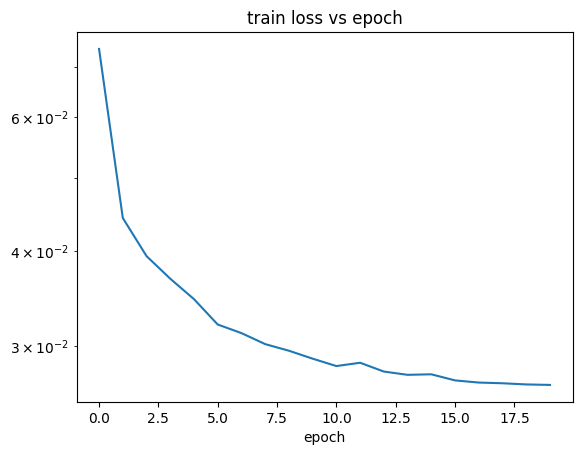

In [ ]:
from tqdm import tqdm
import numpy as np
from torch.utils.data import Subset

dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
# subset_indices = list(range(128 * 10))   # first 1280 samples
# dataset = Subset(dataset, subset_indices)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)



model = ClassConditionalUNet(in_channels = 1, num_classes = 10, num_hiddens = 64).to('cuda')
solver = optim.Adam(params= model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer = solver, gamma = .1**.05)
num_ts = 300
ddpm_sched = ddpm_schedule(beta1= 1e-4, beta2= .02, num_ts = num_ts) 

pipe = DDPM(unet = model)
diffusion_imgs = {}
all_loss = []
for epoch in range(20):
    loop = tqdm(dataloader)
    loss_list = []
    for batch in loop:
        c = batch[1]
        batch = batch[0]
        
        
        loss = pipe(batch,c)
        solver.zero_grad()  
        loss.backward()
        solver.step()

        loop.set_description(f"Train Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
    print(f'Epoch {epoch + 1} loss: ', round(np.mean(np.array(loss_list)),2))
    all_loss.append(np.mean(np.array(loss_list)))
    scheduler.step()


    if (epoch == 5 - 1) | (epoch == 20 - 1):
        _, xt_list = pipe.sample(img_wh =(28,28))
        diffusion_imgs[f'{epoch + 1}'] = xt_list




    #     ddpm_sample(
    # unet: ClassConditionalUNet,
    # ddpm_schedule: dict,
    # c: torch.Tensor,
    # img_wh: tuple[int, int],
    # num_ts: int,
    # guidance_scale: float = 5.0,
    # ddpm_forward(model, ddpm_sched, batch, c =c, p_uncond= .1, num_ts= 300, eval = True)

    
plt.figure()
plt.plot(all_loss)
plt.xlabel('epoch')
plt.title('train loss vs epoch')
plt.yscale('log')
plt.show()

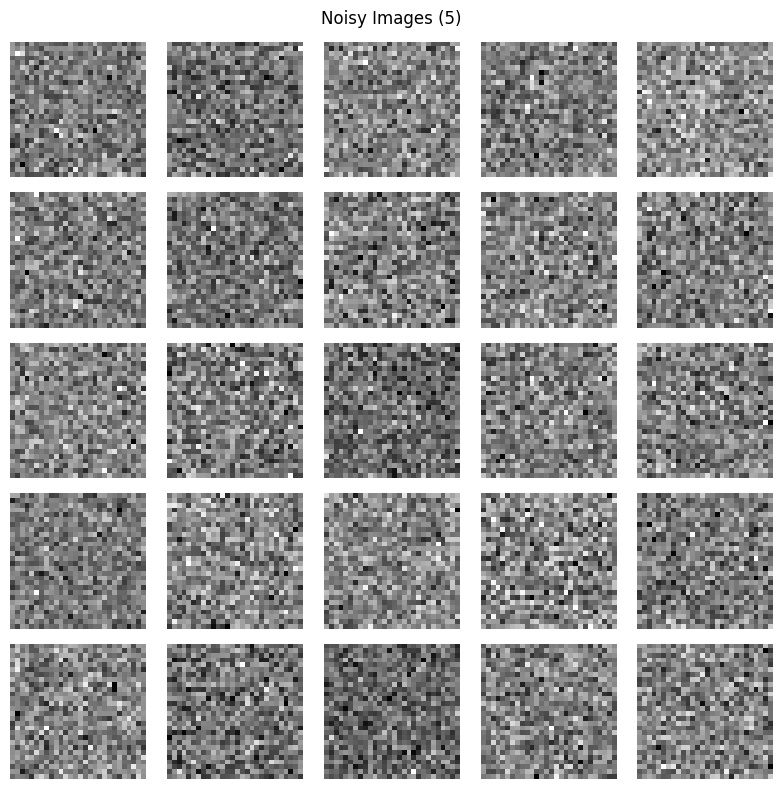

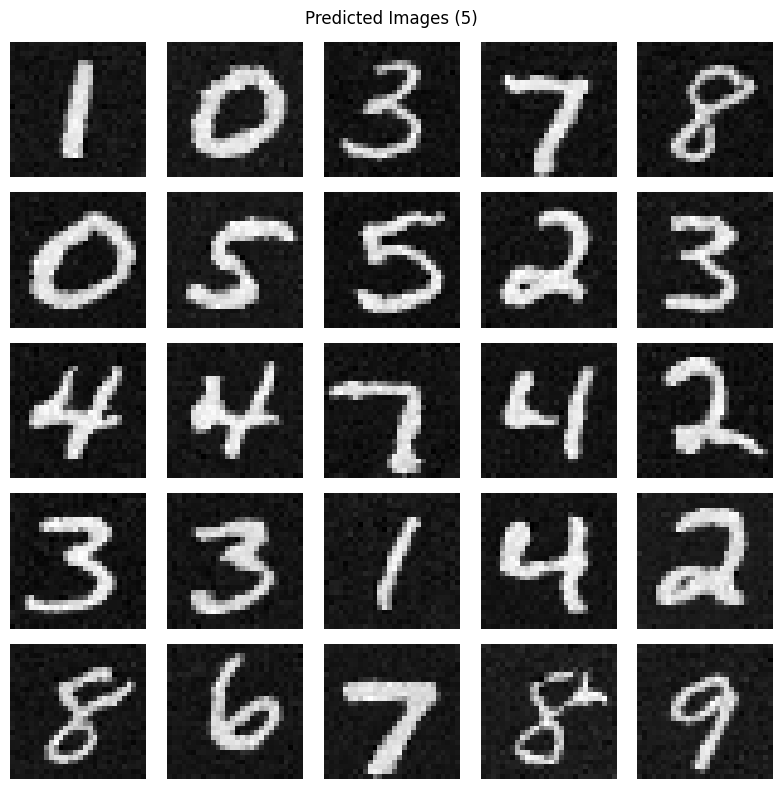

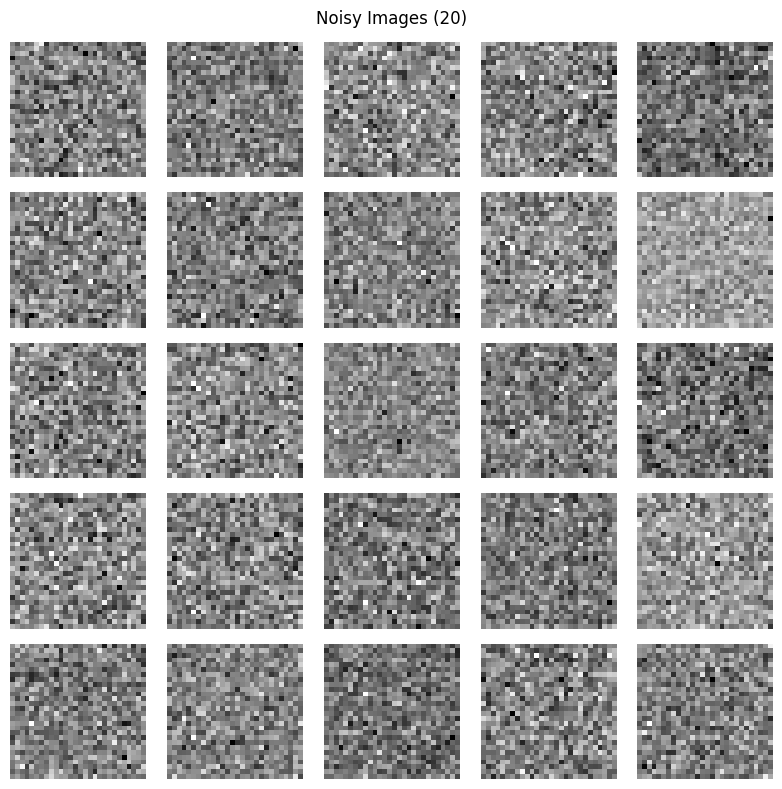

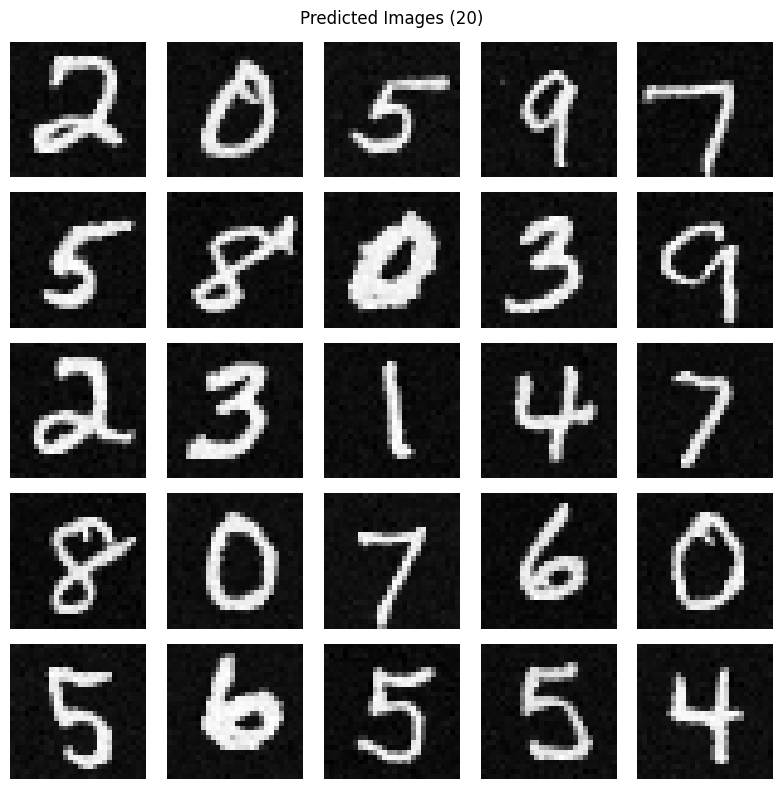

In [ ]:

import matplotlib.pyplot as plt

# assuming: diffusion_imgs[key] is a list of lists or tensors:
#   predictions[i][0] = noisy image
#   predictions[i][-1] = predicted image

for key in diffusion_imgs.keys():

    predictions = diffusion_imgs[key]   # list of 25 predictions

    # --- 5x5 grid of noisy images ---
    plt.figure(figsize=(8,8))
    for i in range(25):
        noisy_img = predictions[i][0].squeeze().cpu().numpy()

        plt.subplot(5,5,i+1)
        plt.imshow(noisy_img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Noisy Images ({key})")
    plt.tight_layout()
    plt.show()


    # --- 5x5 grid of predicted images ---
    plt.figure(figsize=(8,8))
    for i in range(25):
        pred_img = predictions[i][-1].squeeze().cpu().numpy()

        plt.subplot(5,5,i+1)
        plt.imshow(pred_img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Predicted Images ({key})")
    plt.tight_layout()
    plt.show()


